# Energy Anomaly Detection

This notebook uses an unsupervised anomaly detection algorithm to identify unusual power-consumption patterns.

In [1]:
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import IsolationForest
import urllib.request

os.makedirs('../data/energy', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

hh_path = '../data/energy/household_power_consumption.txt'
zip_path = '../data/energy/household_power_consumption.zip'

if not os.path.exists(hh_path):
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip'
    if not os.path.exists(zip_path):
        urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall('../data/energy')

hh = pd.read_csv(hh_path, sep=';', na_values='?', low_memory=False)
hh['datetime'] = pd.to_datetime(hh['Date'] + ' ' + hh['Time'], dayfirst=True)
hh = hh.drop(columns=['Date', 'Time'])
hh = hh.sort_values('datetime').reset_index(drop=True)

numeric_cols = ['Global_active_power','Global_reactive_power','Voltage','Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']
for c in numeric_cols:
    hh[c] = pd.to_numeric(hh[c], errors='coerce')

hh = hh.dropna(subset=['Global_active_power'])
print('Shape:', hh.shape)
print(hh.head())

Shape: (2049280, 8)
   Global_active_power  Global_reactive_power  Voltage  Global_intensity  \
0                4.216                  0.418   234.84              18.4   
1                5.360                  0.436   233.63              23.0   
2                5.374                  0.498   233.29              23.0   
3                5.388                  0.502   233.74              23.0   
4                3.666                  0.528   235.68              15.8   

   Sub_metering_1  Sub_metering_2  Sub_metering_3            datetime  
0             0.0             1.0            17.0 2006-12-16 17:24:00  
1             0.0             1.0            16.0 2006-12-16 17:25:00  
2             0.0             2.0            17.0 2006-12-16 17:26:00  
3             0.0             1.0            17.0 2006-12-16 17:27:00  
4             0.0             1.0            17.0 2006-12-16 17:28:00  


In [2]:
hh_hourly = hh.set_index('datetime')[['Global_active_power']].resample('H').mean().dropna()
hh_hourly['roll_mean_24'] = hh_hourly['Global_active_power'].rolling(24, min_periods=1).mean()
hh_hourly['roll_std_24'] = hh_hourly['Global_active_power'].rolling(24, min_periods=1).std().fillna(0)
hh_hourly['hour'] = hh_hourly.index.hour
hh_hourly['day_of_week'] = hh_hourly.index.dayofweek
print('Hourly shape:', hh_hourly.shape)

Hourly shape: (34168, 5)


/var/folders/7q/d2rx63ls1yx7hhxj4cpwd9qh0000gn/T/ipykernel_68577/3915580813.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hh_hourly = hh.set_index('datetime')[['Global_active_power']].resample('H').mean().dropna()


In [3]:
ANOMALY_FEATURES = ['Global_active_power', 'roll_mean_24', 'roll_std_24', 'hour', 'day_of_week']
X_anomaly = hh_hourly[ANOMALY_FEATURES].dropna()

iso = IsolationForest(contamination=0.03, random_state=42, n_jobs=-1)
hh_hourly.loc[X_anomaly.index, 'anomaly'] = iso.fit_predict(X_anomaly)
hh_hourly['anomaly_label'] = hh_hourly['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

anomaly_count = (hh_hourly['anomaly'] == -1).sum()
print(f'Anomalies detected: {anomaly_count} / {len(hh_hourly)}')
joblib.dump(iso, '../models/anomaly_detector.pkl')

Anomalies detected: 1026 / 34168


['../models/anomaly_detector.pkl']

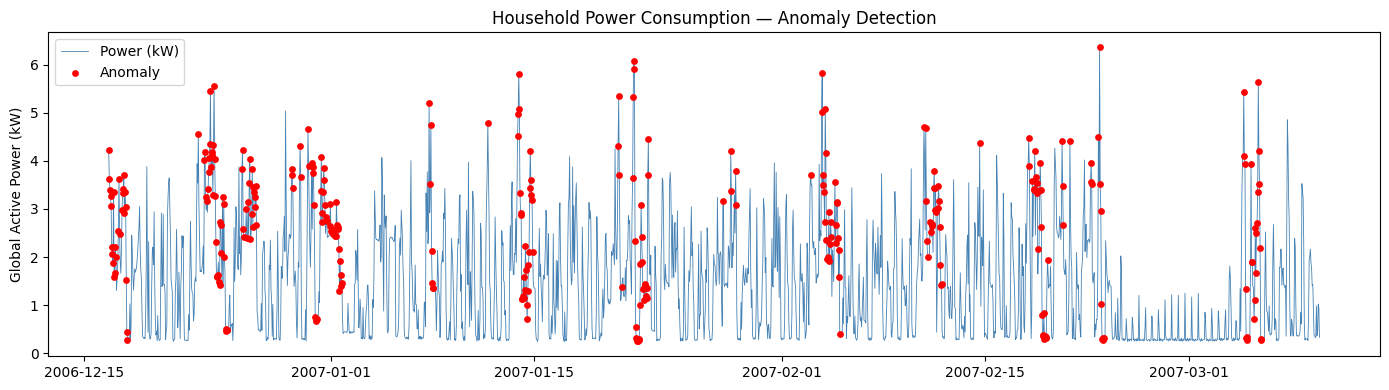

In [4]:
sample_hh = hh_hourly.iloc[:2000]
plt.figure(figsize=(14, 4))
plt.plot(sample_hh.index, sample_hh['Global_active_power'], linewidth=0.6, label='Power (kW)', color='steelblue')
anomalies = sample_hh[sample_hh['anomaly'] == -1]
plt.scatter(anomalies.index, anomalies['Global_active_power'], color='red', s=15, zorder=5, label='Anomaly')
plt.title('Household Power Consumption — Anomaly Detection')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/anomaly_detection.png', dpi=100)
plt.show()